# **TS7:** Filtrado digital lineal de ECG (1ra parte)
## Mariano Pittaluga.
Usando el archivo ecg.mat que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

Ayuda: Los detalles de cómo acceder a ecg.mat los pueden encontrar en lectura_sigs.py
Archivo ECG.mat

- ecg_lead: Registro de ECG muestreado a f s igual 1  KHz durante una prueba de esfuerzo
- qrs_pattern1: Complejo de ondas QRS normal
- heartbeat_pattern1: Latido normal
- heartbeat_pattern2: Latido de origen ventricular
- qrs_detections: vector con las localizaciones (en # de muestras) donde ocurren los latidos


Se pide:
a) Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo.

Ayuda:  Utilice los resultados del ancho de banda estimado del ECG en la Tarea Semanal anterior. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.

b) ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

c) Diseñe al menos dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

Ayuda: Para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-Mc Clellan-Remez. Todos implementados en SciPy.Signal

d)  Evalúe el rendimiento de los filtros que haya diseñado:
    - Verifique que filtra las señales interferentes.
    - Verifique que es inocuo en las zonas donde no hay interferentes.

Bonus:
- Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

# Resolución:
## Diseño de la plantilla:
De la tarea anterior obtuvimos que el ancho de banda efectivo del ECG era aproximadamente 32Hz. Por otro lado, como debemos eliminar el ruido de baja frecuencia debemos definir una frencuencia de corte inferior cercana a los 0Hz. Definimos entonces la banda de paso entre 1Hz y 35Hz. La frecuencia inferior de la stopband la establecemos una decada por debajo en 0,1Hz. Con la superior somos mas exigentes colocandola en 45Hz debido a la cercania del ruido de "alta" frecuencia. Una atenuación en la stopband de 40db y un ripple en la banda de paso de 0,5db definidas a partir de la recomendación del profesor. Finalmente la plantilla obtenida es la siguiente:


In [1]:
import numpy as np
from scipy.io import loadmat
from scipy import signal
import matplotlib.pyplot as plt
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla
# ─────────────────────────────────────────────
#  LECTURA DEL ECG
# ─────────────────────────────────────────────
fs_ecg = 1000  # Hz
fs = fs_ecg

mat_struct = loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)
t_ecg = np.arange(N) / fs

hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()
t_hb1 = np.arange(len(hb_1)) / fs
t_hb2 = np.arange(len(hb_2)) / fs
# ─────────────────────────────────────────────
#  PLANTILLA DEL FILTRO
# ─────────────────────────────────────────────
fc        = [1, 35]    # frecuencias de paso (Hz)
fst       = [0.1, 45] # frecuencias de stop (Hz)
ripple_db = 0.5
att_db    = 40

## Filtros IIR:
### Diseño de los filtros:
Debido a la de fase no lineal de los filtros IIR, utilizamos la función "sosfiltfilt" que aplica el filtro y su conjugado. De esta manera, no se afecta la fase de la señal. En contraposición, la respuesta en modulo es la del filtro al cuadrado. Por ello debemos corregir la plantilla.

In [2]:
# ─────────────────────────────────────────────
#  PARÁMETROS DEL FILTRO
# ─────────────────────────────────────────────
fc        = [1, 35]    # frecuencias de paso (Hz)
fst       = [0.1, 45] # frecuencias de stop (Hz)
ripple_db = 0.25
att_db    = 20

Implementamos filtros maxima planicidad, Cauer y Chebyshev.

In [3]:
# ─────────────────────────────────────────────
#  DISEÑO DE LOS FILTROS
# ─────────────────────────────────────────────
sos_butter = signal.iirdesign(
    wp=fc, ws=fst, gpass=ripple_db, gstop=att_db,
    analog=False, ftype='butter', output='sos', fs=fs
)

sos_cheby = signal.iirdesign(
    wp=fc, ws=fst, gpass=ripple_db, gstop=att_db,
    analog=False, ftype='cheby1', output='sos', fs=fs
)

sos_cauer = signal.iirdesign(
    wp=fc, ws=fst, gpass=ripple_db, gstop=att_db,
    analog=False, ftype='ellip', output='sos', fs=fs
)


### Respuesta en Frecuencia:
Se define una grilla de frecuencias personalizada para aumentar la resolución especificamente en los puntos de interés.
#### Respuesta de Módulo:

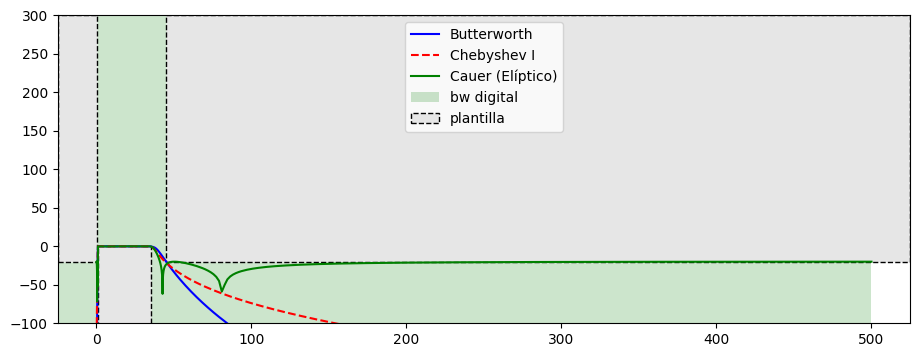

<Figure size 640x480 with 0 Axes>

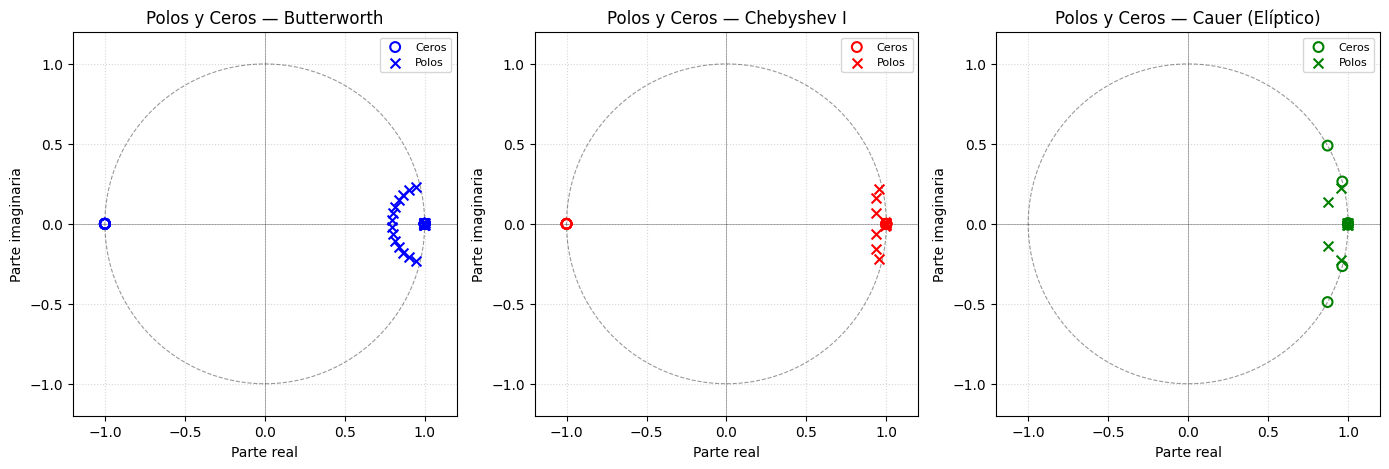

In [4]:
# ─────────────────────────────────────────────
#  GRILLA DE FRECUENCIAS
# ─────────────────────────────────────────────
ww = np.concatenate([
    np.logspace(np.log10(0.01), np.log10(2),   250),
    np.linspace(2.1,            34,             250),
    np.logspace(np.log10(34.1), np.log10(52),  250),
    np.linspace(52.1,           fs / 2,         250),
])
# ─────────────────────────────────────────────
#  RESPUESTA EN FRECUENCIA
# ─────────────────────────────────────────────
_, H_butter = signal.freqz_sos(sos_butter, worN=ww, fs=fs)
mag_butter_dB = 20 * np.log10(np.abs(H_butter) + 1e-300)
phase_butter  = np.unwrap(np.angle(H_butter)) * 180 / np.pi

_, H_cheby = signal.freqz_sos(sos_cheby, worN=ww, fs=fs)
mag_cheby_dB = 20 * np.log10(np.abs(H_cheby) + 1e-300)
phase_cheby  = np.unwrap(np.angle(H_cheby)) * 180 / np.pi

_, H_cauer = signal.freqz_sos(sos_cauer, worN=ww, fs=fs)
mag_cauer_dB = 20 * np.log10(np.abs(H_cauer) + 1e-300)
phase_cauer  = np.unwrap(np.angle(H_cauer)) * 180 / np.pi

# ─────────────────────────────────────────────
#  POLOS Y CEROS
# ─────────────────────────────────────────────
z_but, p_but, _ = signal.sos2zpk(sos_butter)
z_cheb, p_cheb, _ = signal.sos2zpk(sos_cheby)
z_cau,  p_cau,  _ = signal.sos2zpk(sos_cauer)

# ─────────────────────────────────────────────
#  FIGURA 1 — MÓDULO 
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 4))

ax1.plot(ww, mag_butter_dB, 'b',        linewidth=1.5, label='Butterworth')
ax1.plot(ww, mag_cheby_dB,  'r--',      linewidth=1.5, label='Chebyshev I')
ax1.plot(ww, mag_cauer_dB,  color='g',  linewidth=1.5, label='Cauer (Elíptico)')

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = fc, fstop =  fst, ripple = ripple_db, attenuation = att_db, fs = fs)
_ = axes_hdl.legend()

ax1.set_xlim([0, fs / 4])
ax1.set_ylim([-80, 2])
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Magnitud (dB)')
ax1.set_title('Respuesta en Frecuencia — Módulo')
ax1.legend(fontsize=8, loc='lower right', ncol=2)
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()

# ─────────────────────────────────────────────
#  FIGURA 3 — POLOS Y CEROS 
# ─────────────────────────────────────────────
theta = np.linspace(0, 2 * np.pi, 512)
filtros = [
    ('Butterworth',      z_but,  p_but,  'b'),
    ('Chebyshev I',      z_cheb, p_cheb, 'r'),
    ('Cauer (Elíptico)', z_cau,  p_cau,  'g'),
]

fig3, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (nombre, z, p, color) in zip(axes, filtros):
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.4)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='k', linewidth=0.5, alpha=0.4)

    ax.scatter(z.real, z.imag,
               marker='o', s=50, facecolors='none',
               edgecolors=color, linewidths=1.5, zorder=5, label='Ceros')
    ax.scatter(p.real, p.imag,
               marker='x', s=50,
               c=color, linewidths=1.5, zorder=5, label='Polos')

    margin = 0.2
    lim = 1 + margin
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_aspect('equal')
    ax.set_xlabel('Parte real')
    ax.set_ylabel('Parte imaginaria')
    ax.set_title(f'Polos y Ceros — {nombre}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

Como se puede observar, los tres filtros cumplen con las especificaciones de la plantilla modificada. Como es de esperar, el filtro Cauer lo logra con el menor grado, seguido del Chebyshev. Al mismo tiempo, producen un roll off mas importante.

#### Respuesta de Fase:

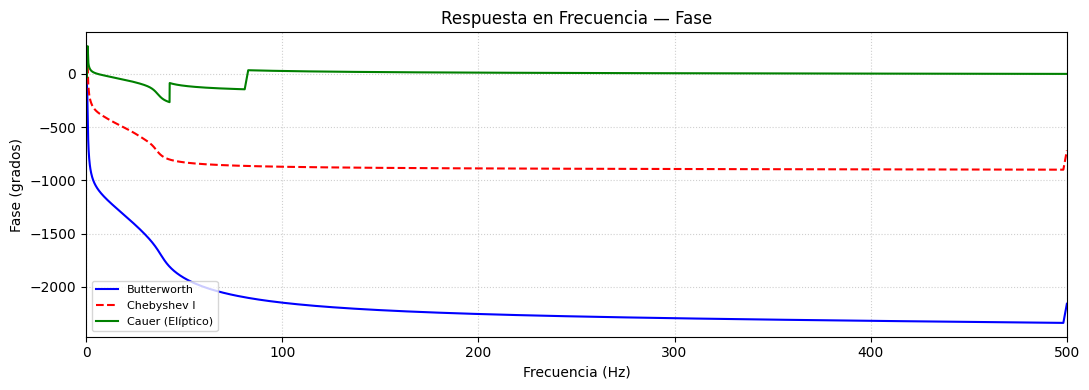

In [5]:
# ─────────────────────────────────────────────
#  FIGURA 2 — FASE 
# ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 4))

ax2.plot(ww, phase_butter, 'b',       linewidth=1.5, label='Butterworth')
ax2.plot(ww, phase_cheby,  'r--',     linewidth=1.5, label='Chebyshev I')
ax2.plot(ww, phase_cauer,  color='g', linewidth=1.5, label='Cauer (Elíptico)')


ax2.set_xlim([0, fs / 2])
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Fase (grados)')
ax2.set_title('Respuesta en Frecuencia — Fase')
ax2.legend(fontsize=8)
ax2.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()


Aqui se pueden apreciar los incovenientes que traen filtros como el Cauer para la linealidad de la fase. Sin embargo, como estamos aplicando el filtro con "sosfilfilt" no vamos a percibir su efecto en la señal.

### Filtrado de la Señal:
#### ECG sin señales interferentes:

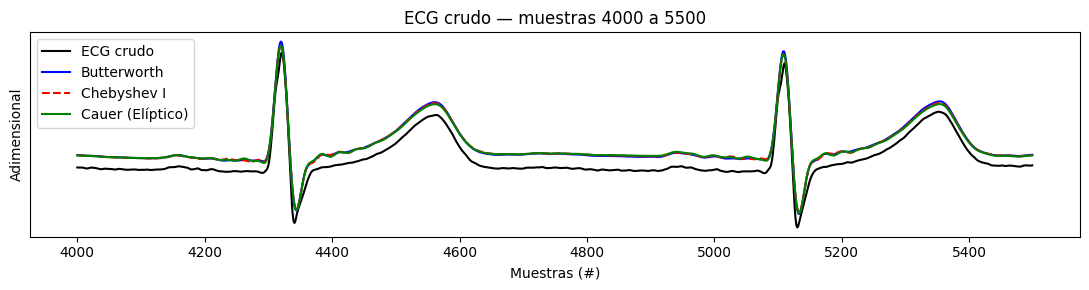

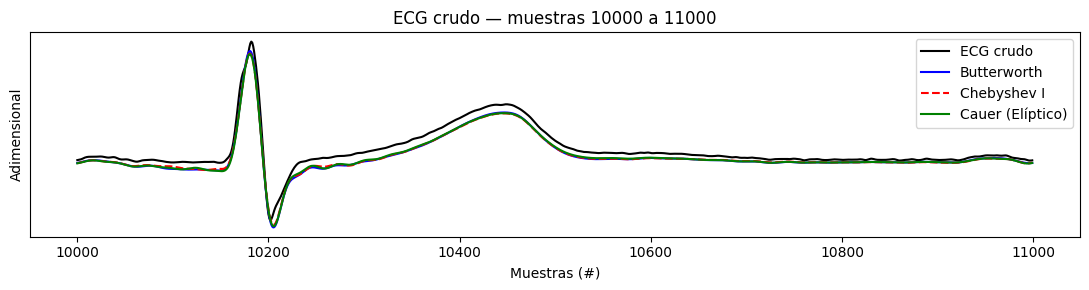

In [6]:
# ─────────────────────────────────────────────
#  FILTRADO DEL ECG IIR
# ─────────────────────────────────────────────
ecg_butter = signal.sosfiltfilt(sos_butter, ecg_one_lead)
ecg_cheby  = signal.sosfiltfilt(sos_cheby,  ecg_one_lead)
ecg_cauer  = signal.sosfiltfilt(sos_cauer,  ecg_one_lead)

###################################
#%% Regiones de interés sin ruido #
###################################
regs_ruido = (
    [4000, 5500],
    [10000, 11000],
)

for ii in regs_ruido:
    zoom = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
    plt.figure(figsize=(11, 3))
    plt.plot(zoom, ecg_one_lead[zoom], 'k', label='ECG crudo', linewidth=1.5)
    plt.plot(zoom, ecg_butter[zoom],   'b',   linewidth=1.5, label='Butterworth')
    plt.plot(zoom, ecg_cheby[zoom],    'r--', linewidth=1.5, label='Chebyshev I')
    plt.plot(zoom, ecg_cauer[zoom],    'g',   linewidth=1.5, label='Cauer (Elíptico)')
    plt.title(f'ECG crudo — muestras {ii[0]} a {ii[1]}')
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.gca().legend()
    plt.gca().set_yticks(())
    plt.tight_layout()

Lo primero que notamos es un desplazamiento general de con respecto a la señal cruda. Esto se debe a la eliminación de las bajas frecuencias, incluyendo 0Hz. Notamos un seguimiento de la señal muy preciso excepto en las zonas mas planas donde la respuesta filtrada (de los tres filtros) presenta una oscilación que no estaba originalmente.

#### ECG con señales interferentes:

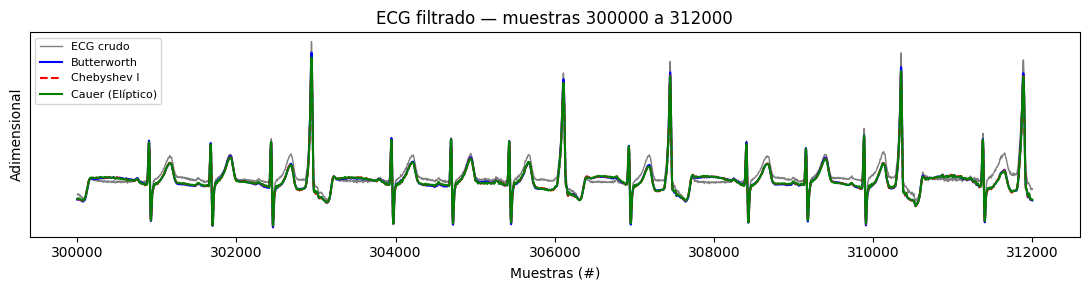

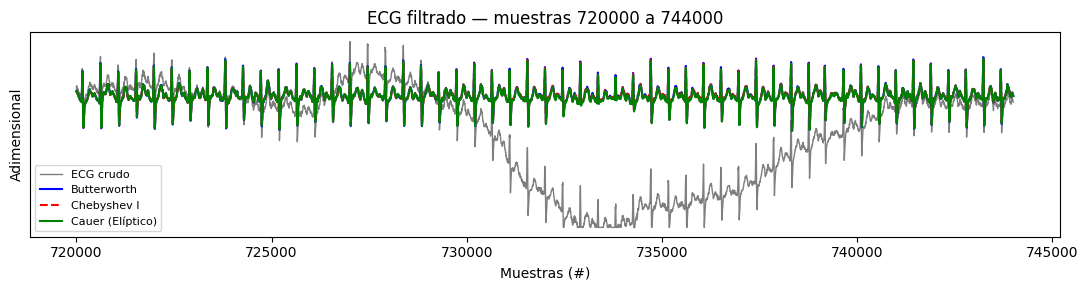

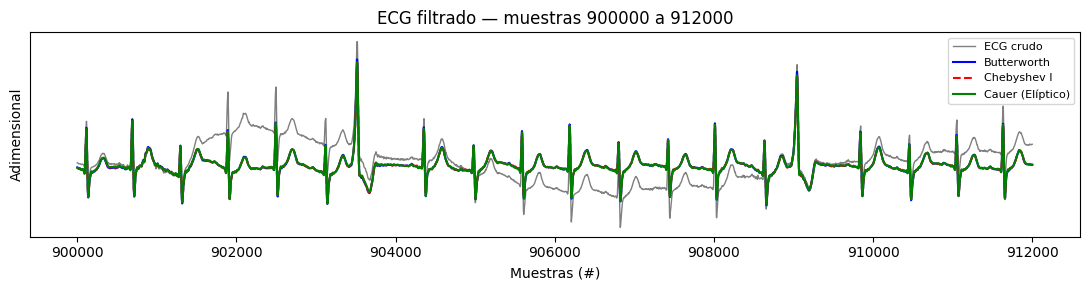

In [7]:
###################################
#%% Regiones de interés con ruido #
###################################
regs_filtradas = (
    np.array([5,  5.2 ]) * 60 * fs,
    np.array([12, 12.4]) * 60 * fs,
    np.array([15, 15.2]) * 60 * fs,
)

for ii in regs_filtradas:
    zoom = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
    plt.figure(figsize=(11, 3))
    plt.plot(zoom, ecg_one_lead[zoom], 'k',   linewidth=1,   label='ECG crudo',        alpha=0.5)
    plt.plot(zoom, ecg_butter[zoom],   'b',   linewidth=1.5, label='Butterworth')
    plt.plot(zoom, ecg_cheby[zoom],    'r--', linewidth=1.5, label='Chebyshev I')
    plt.plot(zoom, ecg_cauer[zoom],    'g',   linewidth=1.5, label='Cauer (Elíptico)')
    plt.title(f'ECG filtrado — muestras {int(ii[0])} a {int(ii[1])}')
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.gca().legend(fontsize=8)
    plt.gca().set_yticks(())
    plt.tight_layout()

plt.show()

En el primer gráfico podemos observar como se elimina el ripple de alta frecuencia satisfactoriamente. Los siguientes gráficos son una excelente demostracion de la atenuación de una oscilación de baja frecuencia, posiblemente debido al movimiento de los electrodos.
## Filtros FIR:
### Diseño de los filtros:
En este caso, el proceso de diseño se torna mas "artesanal" ya que debemos ir modificando ligeramente la plantilla y el numero de Taps con el objetivo de cumplir con la plantilla. Cabe destacar que para el Metodo de Ventana se utiliza una plantilla con atenuacion de 20dB. Esto es porque la aplicación del filtro generaba una rotacion de fase de "j" y para corregirla se aplico dos veces el filtrado y se invertio el signo.

In [8]:
# ─────────────────────────────────────────────
#  PLANTILLA DEL FILTRO
# ─────────────────────────────────────────────
fc = [1, 35]    # frecuencias de paso (Hz)
fst = [0.1, 45]  # frecuencias de stop (Hz)
ripple_db = 1
att_db = 40
# Para el Win es la mitad porque lo paso dos veces

# ─────────────────────────────────────────────
#  PARÁMETROS Y DISEÑO DEL FILTRO
# ─────────────────────────────────────────────

# odd numtaps, antisymmetric is False, type I filter is produced
# even numtaps, antisymmetric is False, type II filter is produced
# odd numtaps, antisymmetric is True, type III filter is produced
# even numtaps, antisymmetric is True, type IV filter is produced

freq = [0, 0.1, 1, 35, 45, 500]
freq_win = freq
freq_ls = [0, 0.1, 1, 35, 36, 500]
freq_rz = [0, 0.1, 1, 35, 36, 500]

gain = [0, 0, 1, 1, 0, 0]
gain_win = gain
gain_ls = [0, 0, 1, 1, 0, 0]
gain_rz = [0, 1, 0]

weigth_rz = [1, 1, 10]

Ntaps_win = 1101
Ntaps_ls = 1801
Ntaps_rz = 1501
win = 'boxcar'

b_win = signal.firwin2(numtaps=Ntaps_win, freq=freq_win,
                       gain=gain_win, window=win, antisymmetric=True, fs=fs)
b_ls = signal.firls(numtaps=Ntaps_ls, bands=freq_ls,
                    desired=gain_ls, weight=None, fs=fs)

b_rz = signal.remez(numtaps=Ntaps_rz, bands=freq_rz, desired=gain_rz, weight=weigth_rz, 
      type='bandpass', maxiter=25, fs=fs)

### Respuesta en Frecuencia:
Se define una grilla de frecuencias personalizada para aumentar la resolución especificamente en los puntos de interés.
#### Respuesta de Módulo:

/home/marianop/pds/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


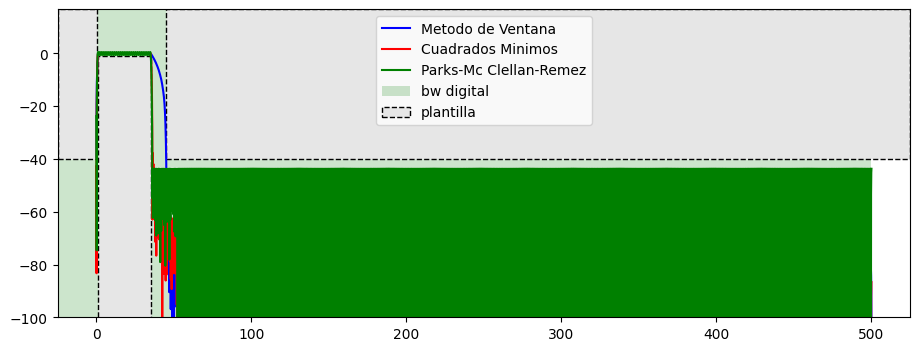

<Figure size 640x480 with 0 Axes>

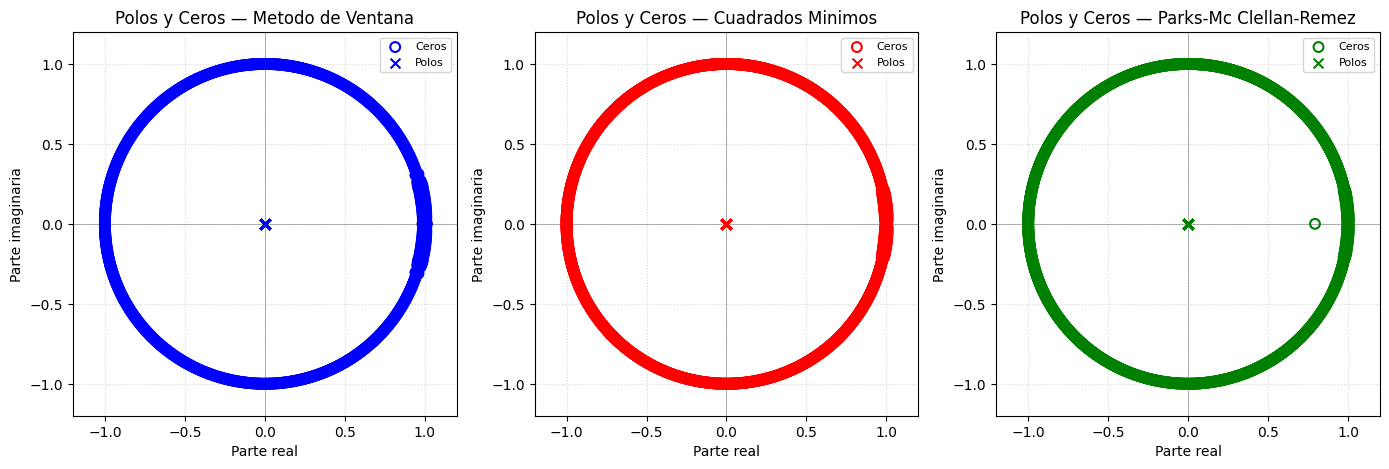

In [9]:
# ─────────────────────────────────────────────
#  RESPUESTA EN FRECUENCIA
# ─────────────────────────────────────────────
ww = np.concatenate([
    np.logspace(np.log10(0.01), np.log10(2),   250),
    np.linspace(2.1,            34,             N),
    np.logspace(np.log10(34.1), np.log10(52),  250),
    np.linspace(52.1,           fs / 2,         N),
])
_, H_win = signal.freqz(b_win, worN=ww, fs=fs)
mag_win_dB = 20 * np.log10(np.abs(H_win) + 1e-300)
phase_win = np.unwrap(np.angle(H_win)) * 180 / np.pi

_, H_ls = signal.freqz(b_ls, worN=ww, fs=fs)
mag_ls_dB = 20 * np.log10(np.abs(H_ls) + 1e-300)
phase_ls = np.unwrap(np.angle(H_ls)) * 180 / np.pi

_, H_rz = signal.freqz(b_rz, worN=ww, fs=fs)
mag_rz_dB = 20 * np.log10(np.abs(H_rz) + 1e-300)
phase_rz = np.unwrap(np.angle(H_rz)) * 180 / np.pi

# ─────────────────────────────────────────────
#  POLOS Y CEROS
# ─────────────────────────────────────────────
z_win = np.roots(b_win)          # ceros
p_win = np.zeros(len(b_win) - 1)  # todos los polos en z = 0

z_ls = np.roots(b_ls)          # ceros
p_ls = np.zeros(len(b_ls) - 1)  # todos los polos en z = 0

z_rz = np.roots(b_rz)          # ceros
p_rz = np.zeros(len(b_rz) - 1)  # todos los polos en z = 0

# ─────────────────────────────────────────────
#  FIGURA 1 — MÓDULO
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 4))

ax1.plot(ww, mag_win_dB, 'b', linewidth=1.5, label='Metodo de Ventana')
ax1.plot(ww, mag_ls_dB, 'r', linewidth=1.5, label='Cuadrados Minimos')
ax1.plot(ww, mag_rz_dB, 'g', linewidth=1.5, label='Parks-Mc Clellan-Remez')

axes_hdl = plt.gca()

plot_plantilla(filter_type='bandpass', fpass=fc, fstop=fst,
               ripple=ripple_db, attenuation=att_db, fs=fs)
_ = axes_hdl.legend()

ax1.set_xlim([0, fs / 2])
ax1.set_ylim([-80, 5])
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Magnitud (dB)')
ax1.set_title('Respuesta en Frecuencia — Módulo')
ax1.legend(fontsize=8, loc='lower right', ncol=2)
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()

# ─────────────────────────────────────────────
#  FIGURA 3 — POLOS Y CEROS
# ─────────────────────────────────────────────
theta = np.linspace(0, 2 * np.pi, 512)
filtros = [
    ('Metodo de Ventana',      z_win,  p_win,  'b'),
    ('Cuadrados Minimos',      z_ls, p_ls, 'r'),
    ('Parks-Mc Clellan-Remez',      z_rz, p_rz, 'g')
]

fig3, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (nombre, z, p, color) in zip(axes, filtros):
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.4)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='k', linewidth=0.5, alpha=0.4)

    ax.scatter(z.real, z.imag,
               marker='o', s=50, facecolors='none',
               edgecolors=color, linewidths=1.5, zorder=5, label='Ceros')
    ax.scatter(p.real, p.imag,
               marker='x', s=50,
               c=color, linewidths=1.5, zorder=5, label='Polos')

    margin = 0.2
    lim = 1 + margin
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_aspect('equal')
    ax.set_xlabel('Parte real')
    ax.set_ylabel('Parte imaginaria')
    ax.set_title(f'Polos y Ceros — {nombre}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()


Podemos apreciar en principio la gran cantidad de singularidades que tenemos con respecto a los filtros IIR de la parte anterior. Por otro lado, podemos notar como con el Metodo de Ventana cumplimos la plantilla de forma menos exigente utilizando menor cantidad de Taps. Sin embargo, para el metodo de Cuadrados Minimos Y Remez aplicamos una predistorsion de la plantilla para lograr un mayor roll-off. Esto fue especialmente necesario en Cuadrados Minimos ya que de otra forma se producia un sobrepico en la transicion entre la banda de paso y la stopband. Para Remez tambien fue necesario utilizar los pesos para que cumpliera con las altas frecuencias. Notar que la mayor diferencia entre estos dos metodos es que Remez presenta respuesta equi-ripple.
#### Respuesta de Fase:

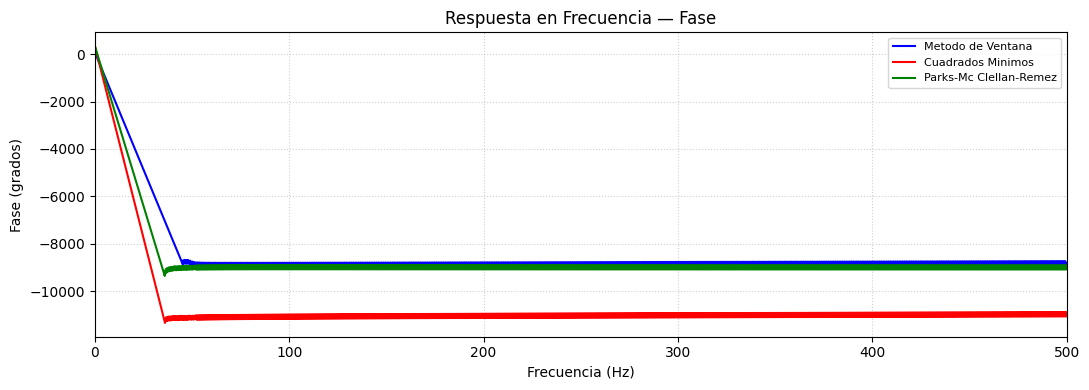

In [10]:
# ─────────────────────────────────────────────
#  FIGURA 2 — FASE
# ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 4))

ax2.plot(ww, phase_win, 'b', linewidth=1.5, label='Metodo de Ventana')
ax2.plot(ww, phase_ls,  'r', linewidth=1.5, label='Cuadrados Minimos')
ax2.plot(ww, phase_rz, 'g', linewidth=1.5, label='Parks-Mc Clellan-Remez')

ax2.set_xlim([0, fs / 2])
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Fase (grados)')
ax2.set_title('Respuesta en Frecuencia — Fase')
ax2.legend(fontsize=8)
ax2.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()

En este gráfico podemos apreciar una de las grandes ventajas de los filtro FIR, la fase lineal. Esta caracteristica implica que no presenta distorsión de fase y genera un retardo constante para todas las frecuencias.
### Filtrado de la Señal:
#### ECG sin señales interferentes:
Como se menciono antes, para el filtrado de Metodo de Ventana lo aplicamos dos veces y e invertimos el signo para corregir el desfase de 90°. Para los tres filtros corregimos el retardo para que todos los graficos coincidan en tiempo.

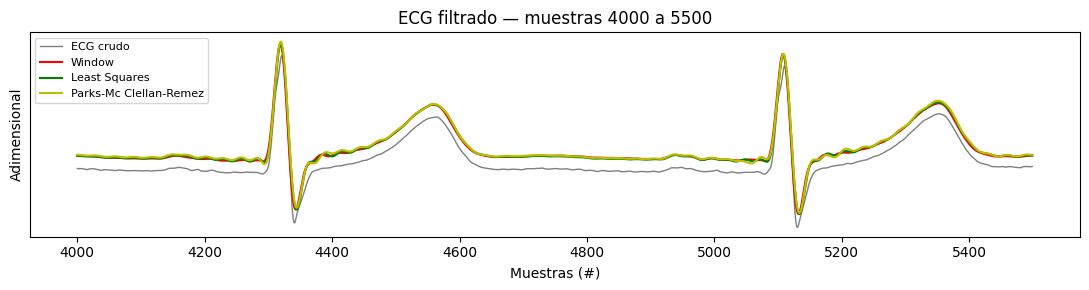

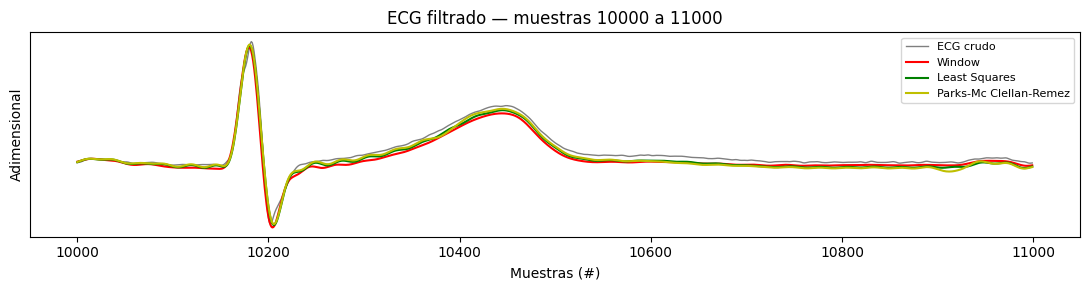

In [11]:
# ─────────────────────────────────────────────
#  FILTRADO DEL ECG IIR
# ─────────────────────────────────────────────
ecg_win  = signal.lfilter(b_win, 1,   ecg_one_lead)
ecg_win  = signal.lfilter(b_win, 1,   ecg_win)
ecg_win = np.concatenate((ecg_win[Ntaps_win:], np.zeros(Ntaps_win)))
ecg_win = -ecg_win

ecg_ls  = signal.lfilter(b_ls, 1,   ecg_one_lead)
ecg_ls  =  np.concatenate((ecg_ls[Ntaps_ls//2:], np.zeros(Ntaps_ls//2)))

ecg_rz = signal.lfilter(b_rz, 1,   ecg_one_lead)
ecg_rz  =  np.concatenate((ecg_rz[Ntaps_rz//2:], np.zeros(Ntaps_rz//2)))

###################################
#%% Regiones de interés sin ruido #
###################################
regs_ruido = (
    [4000, 5500],
    [10000, 11000],
)
    
for ii in regs_ruido:
    zoom = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
    plt.figure(figsize=(11, 3))
    plt.plot(zoom, ecg_one_lead[zoom], 'k',   linewidth=1,   label='ECG crudo',        alpha=0.5)
    plt.plot(zoom, ecg_win[zoom],    'r', linewidth=1.5, label='Window')
    plt.plot(zoom, ecg_ls[zoom],    'g',   linewidth=1.5, label='Least Squares')
    plt.plot(zoom, ecg_rz[zoom],    'y',   linewidth=1.5, label='Parks-Mc Clellan-Remez')
    plt.title(f'ECG filtrado — muestras {int(ii[0])} a {int(ii[1])}')
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.gca().legend(fontsize=8)
    plt.gca().set_yticks(())
    plt.tight_layout()

El resultado es similar al filtrado IIR; Notamos la eliminación de la continua. Por otro lado, podemos apreciar que los metodos Remez y Cuadrados Minimos acentuan la caracteristica oscilatoria mencionada para los filtros IIR.
#### ECG con señales interferentes:

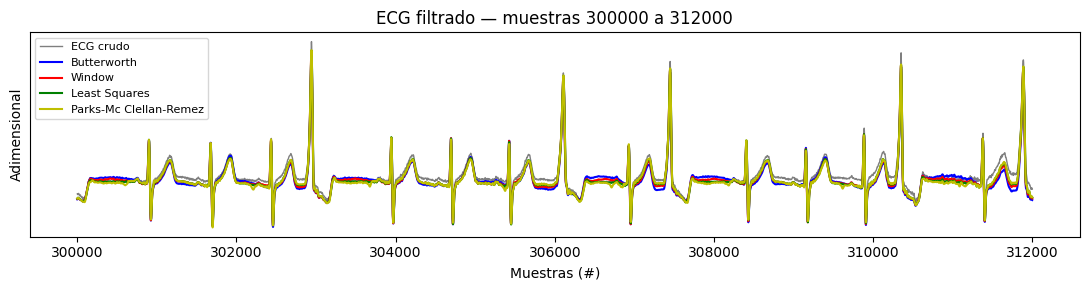

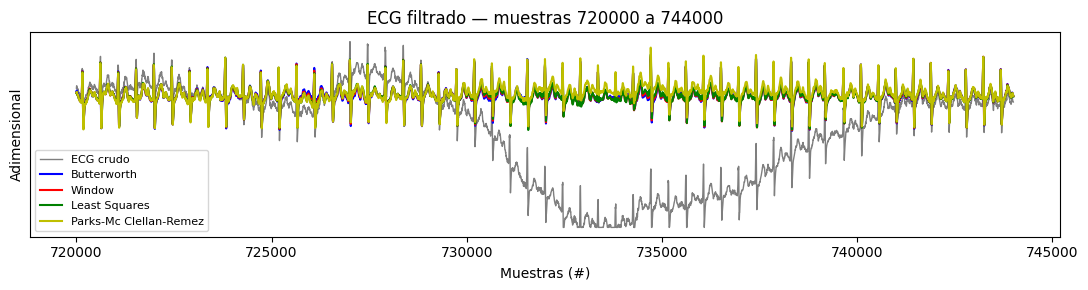

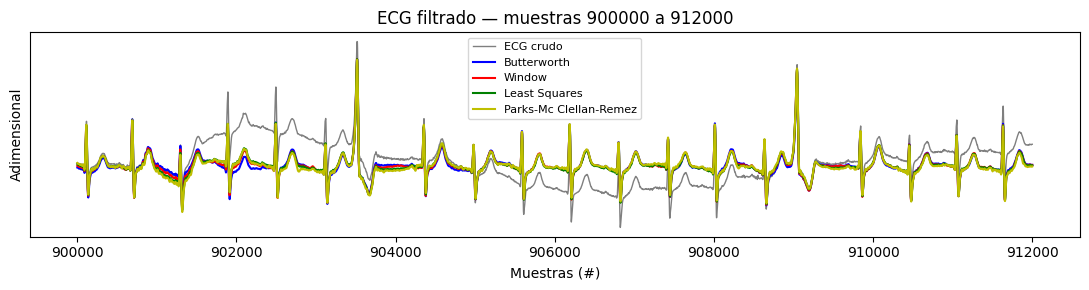

In [12]:
###################################
#%% Regiones de interés con ruido #
###################################
regs_filtradas = (
    np.array([5,  5.2 ]) * 60 * fs,
    np.array([12, 12.4]) * 60 * fs,
    np.array([15, 15.2]) * 60 * fs,
)

for ii in regs_filtradas:
    zoom = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
    plt.figure(figsize=(11, 3))
    plt.plot(zoom, ecg_one_lead[zoom], 'k',   linewidth=1,   label='ECG crudo',        alpha=0.5)
    plt.plot(zoom, ecg_butter[zoom],   'b',   linewidth=1.5, label='Butterworth')
    plt.plot(zoom, ecg_win[zoom],    'r', linewidth=1.5, label='Window')
    plt.plot(zoom, ecg_ls[zoom],    'g',   linewidth=1.5, label='Least Squares')
    plt.plot(zoom, ecg_rz[zoom],    'y',   linewidth=1.5, label='Parks-Mc Clellan-Remez')
    plt.title(f'ECG filtrado — muestras {int(ii[0])} a {int(ii[1])}')
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.gca().legend(fontsize=8)
    plt.gca().set_yticks(())
    plt.tight_layout()

plt.show()

De nuevo podemos apreciar la eliminacion tanto de la baja frecuencia, como el ripple de alta frecuencia. Aquí la oscilación que agrega el Metodo Remez llama verdaderamente la atención al compararla con los otros dos metodos. No parece "seguir" a la señal original en algunos puntos. Esto debe ser tenido en cuenta si existe informacion sensible en el modulo de la señal.
## Bonus:
### Diseño de los filtros:
Ahora repetimos el experimento sobre una señal muestreada de la nota LA en una guitarra electrica. La misma se conecto con su jack 6.2mm a la entrada para micrófono de la PC por medio de un adaptador. Entonces, se utilizó el DAC de la misma PC para realizar el muestreo. Filtraremos la misma con filtro IIR. Construimos la plantilla teniendo en cuenta el ancho de banda calculado en la anterior tarea:

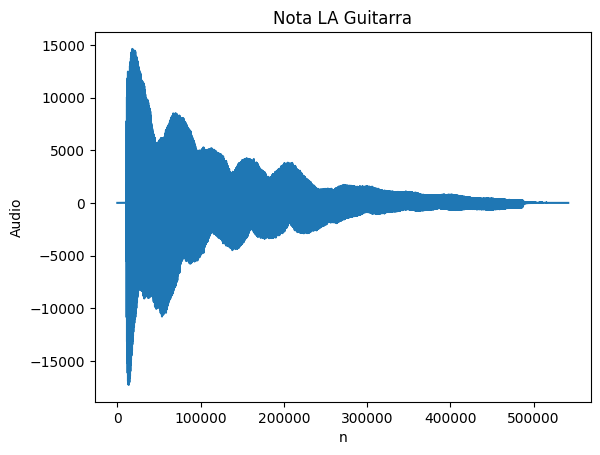

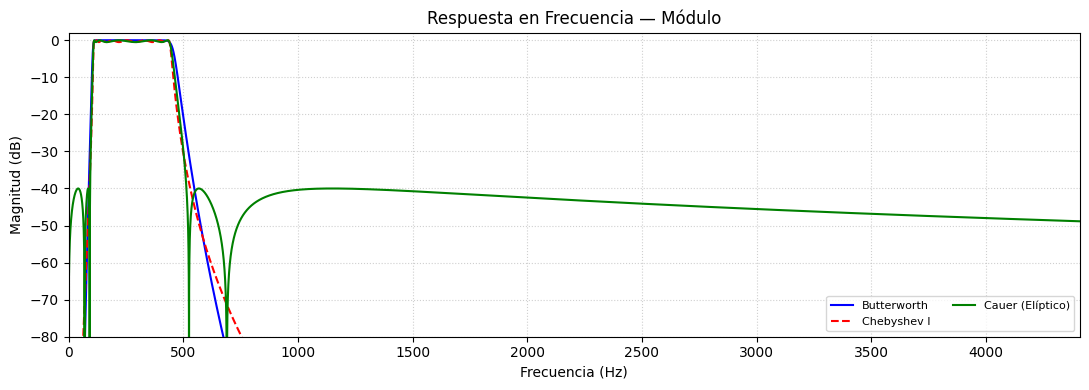

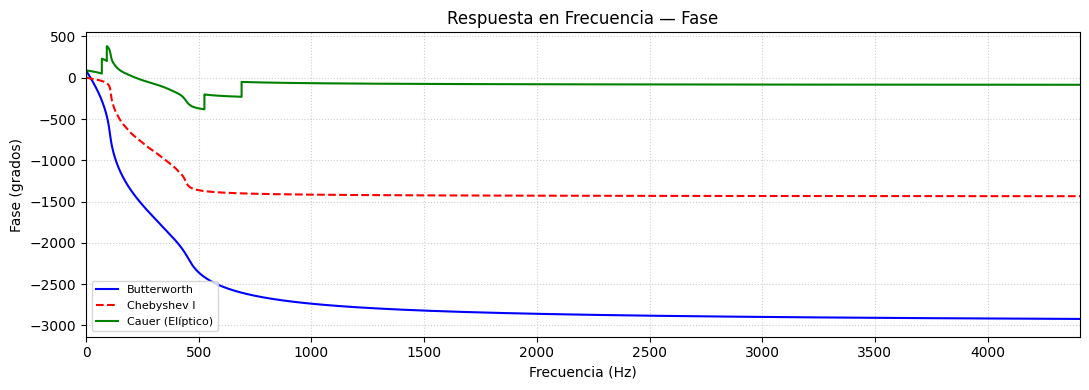

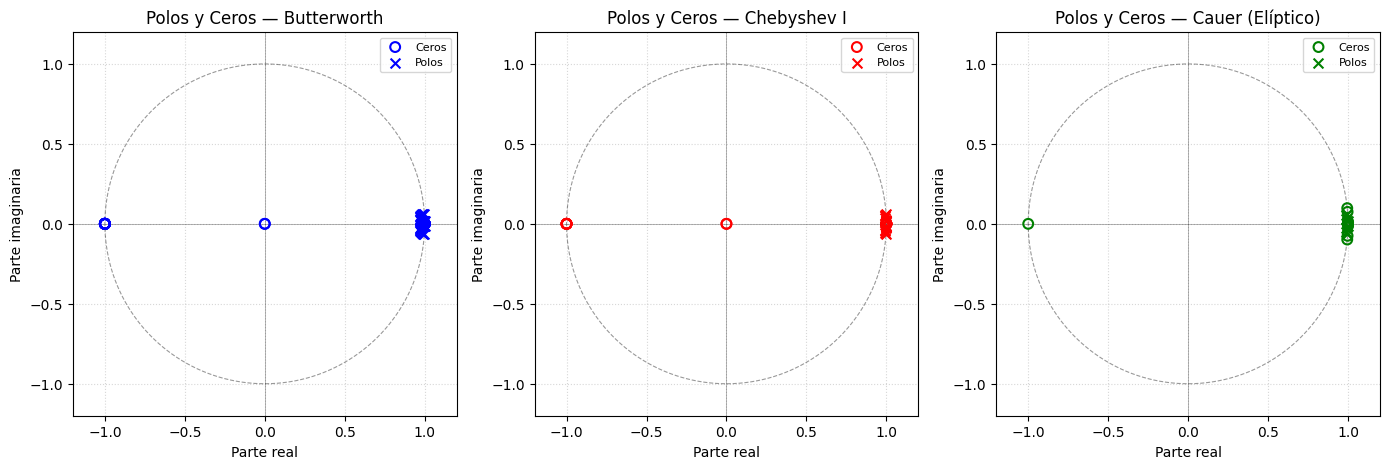

In [17]:
# Señal Guitarra
fs_la, la = sio.wavfile.read('NotaLaGuitarra.wav')
la = la - np.mean(la) # Elimino la potencia de continua.
Nla = len(la)
deltaf_la = fs_la/Nla

plt.figure()
plt.xlabel('n')
plt.ylabel('Audio')
plt.title('Nota LA Guitarra')
plt.plot(la)

# ─────────────────────────────────────────────
#  PLANTILLA DEL FILTRO
# ─────────────────────────────────────────────
fc        = [110, 440]    # frecuencias de paso (Hz)
fst       = [55, 550] # frecuencias de stop (Hz)
ripple_db = 0.5
att_db    = 40
# ─────────────────────────────────────────────
#  DISEÑO DE LOS FILTROS
# ─────────────────────────────────────────────
sos_butter = signal.iirdesign(
    wp=fc, ws=fst, gpass=ripple_db, gstop=att_db,
    analog=False, ftype='butter', output='sos', fs=fs_la
)

sos_cheby = signal.iirdesign(
    wp=fc, ws=fst, gpass=ripple_db, gstop=att_db,
    analog=False, ftype='cheby1', output='sos', fs=fs_la
)

sos_cauer = signal.iirdesign(
    wp=fc, ws=fst, gpass=ripple_db, gstop=att_db,
    analog=False, ftype='ellip', output='sos', fs=fs_la
)
# ─────────────────────────────────────────────
#  RESPUESTA EN FRECUENCIA
# ─────────────────────────────────────────────
ww = np.linspace(0, fs_la//2, Nla)

_, H_butter = signal.freqz_sos(sos_butter, worN=ww, fs=fs_la)
mag_butter_dB = 20 * np.log10(np.abs(H_butter) + 1e-300)
phase_butter  = np.unwrap(np.angle(H_butter)) * 180 / np.pi

_, H_cheby = signal.freqz_sos(sos_cheby, worN=ww, fs=fs_la)
mag_cheby_dB = 20 * np.log10(np.abs(H_cheby) + 1e-300)
phase_cheby  = np.unwrap(np.angle(H_cheby)) * 180 / np.pi

_, H_cauer = signal.freqz_sos(sos_cauer, worN=ww, fs=fs_la)
mag_cauer_dB = 20 * np.log10(np.abs(H_cauer) + 1e-300)
phase_cauer  = np.unwrap(np.angle(H_cauer)) * 180 / np.pi

# ─────────────────────────────────────────────
#  POLOS Y CEROS
# ─────────────────────────────────────────────
z_but, p_but, _ = signal.sos2zpk(sos_butter)
z_cheb, p_cheb, _ = signal.sos2zpk(sos_cheby)
z_cau,  p_cau,  _ = signal.sos2zpk(sos_cauer)

# ─────────────────────────────────────────────
#  FIGURA 1 — MÓDULO 
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 4))

ax1.plot(ww, mag_butter_dB, 'b',        linewidth=1.5, label='Butterworth')
ax1.plot(ww, mag_cheby_dB,  'r--',      linewidth=1.5, label='Chebyshev I')
ax1.plot(ww, mag_cauer_dB,  color='g',  linewidth=1.5, label='Cauer (Elíptico)')

axes_hdl = plt.gca()

#plot_plantilla(filter_type = 'bandpass', fpass = fc, fstop =  fst, ripple = ripple_db, attenuation = att_db, fs = fs_la)
_ = axes_hdl.legend()

ax1.set_xlim([0, fs_la /10])
ax1.set_ylim([-80, 2])
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Magnitud (dB)')
ax1.set_title('Respuesta en Frecuencia — Módulo')
ax1.legend(fontsize=8, loc='lower right', ncol=2)
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
# ─────────────────────────────────────────────
#  FIGURA 2 — FASE 
# ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 4))

ax2.plot(ww, phase_butter, 'b',       linewidth=1.5, label='Butterworth')
ax2.plot(ww, phase_cheby,  'r--',     linewidth=1.5, label='Chebyshev I')
ax2.plot(ww, phase_cauer,  color='g', linewidth=1.5, label='Cauer (Elíptico)')


ax2.set_xlim([0, fs_la / 10])
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Fase (grados)')
ax2.set_title('Respuesta en Frecuencia — Fase')
ax2.legend(fontsize=8)
ax2.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
# ─────────────────────────────────────────────
#  FIGURA 3 — POLOS Y CEROS 
# ─────────────────────────────────────────────
theta = np.linspace(0, 2 * np.pi, 512)
filtros = [
    ('Butterworth',      z_but,  p_but,  'b'),
    ('Chebyshev I',      z_cheb, p_cheb, 'r'),
    ('Cauer (Elíptico)', z_cau,  p_cau,  'g'),
]

fig3, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (nombre, z, p, color) in zip(axes, filtros):
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8, alpha=0.4)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='k', linewidth=0.5, alpha=0.4)

    ax.scatter(z.real, z.imag,
               marker='o', s=50, facecolors='none',
               edgecolors=color, linewidths=1.5, zorder=5, label='Ceros')
    ax.scatter(p.real, p.imag,
               marker='x', s=50,
               c=color, linewidths=1.5, zorder=5, label='Polos')

    margin = 0.2
    lim = 1 + margin
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_aspect('equal')
    ax.set_xlabel('Parte real')
    ax.set_ylabel('Parte imaginaria')
    ax.set_title(f'Polos y Ceros — {nombre}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

### Filtrado de la Señal:

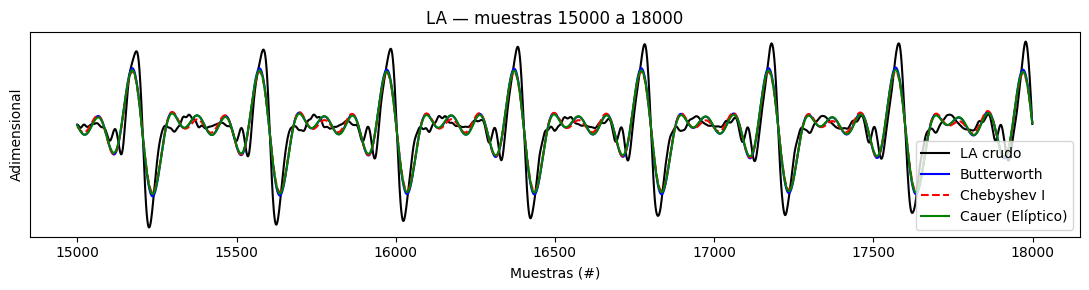

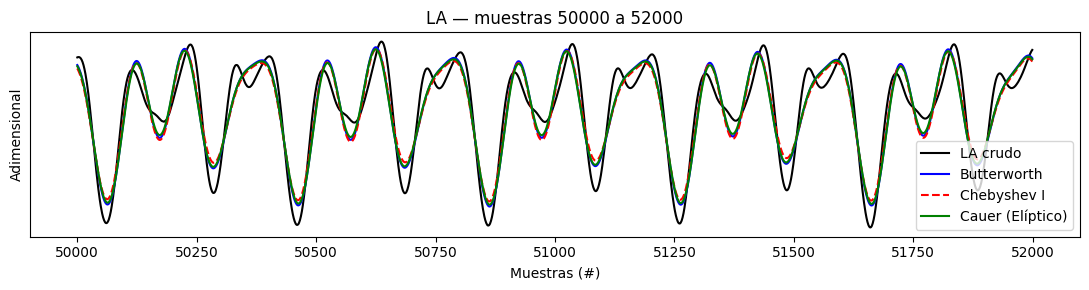

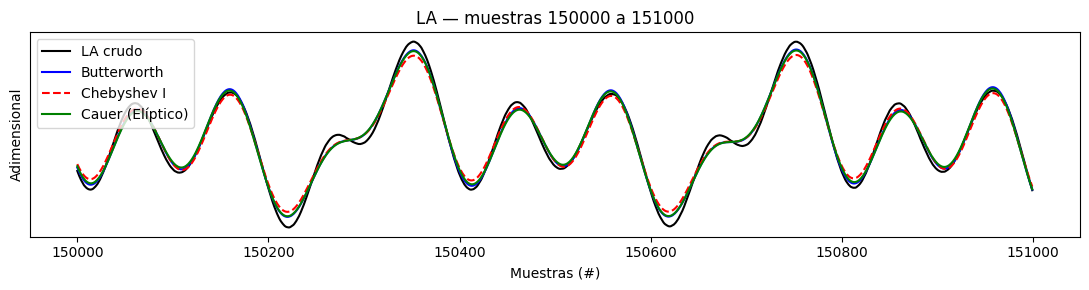

In [28]:
# ─────────────────────────────────────────────
#  FILTRADO NOTA LA
# ─────────────────────────────────────────────
la_butter = signal.sosfiltfilt(sos_butter, la)
la_cheby  = signal.sosfiltfilt(sos_cheby,  la)
la_cauer  = signal.sosfiltfilt(sos_cauer,  la)

regs_ruido = (
    [15000, 18000],
    [50000, 52000],
    [150000, 151000],
)

for ii in regs_ruido:
    zoom = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
    plt.figure(figsize=(11, 3))
    plt.plot(zoom, la[zoom], 'k', label='LA crudo', linewidth=1.5)
    plt.plot(zoom, la_butter[zoom],   'b',   linewidth=1.5, label='Butterworth')
    plt.plot(zoom, la_cheby[zoom],    'r--', linewidth=1.5, label='Chebyshev I')
    plt.plot(zoom, la_cauer[zoom],    'g',   linewidth=1.5, label='Cauer (Elíptico)')
    plt.title(f'LA — muestras {ii[0]} a {ii[1]}')
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.gca().legend()
    plt.gca().set_yticks(())
    plt.tight_layout()

En los gráficos de la nota filtrada podemos notar que para bajas frecnuencias (grafico 3) la señal filtrada sigue correctamente la original. En cambio, para los dos primeros graficos, la señal filtrada no se asemeja mucho a la original. Esto nos indica que estamos posiblemente filtrando armonicos con peso considerable para la señal que quedan fuera del ancho de banda. Si bien la señal de salida sea un tono LA mas "puro", estariamos perdiendo la respeesta espectral que representa al sonido de una guitarra.

## Conclusión:
Se identificaron las diferencias en el diseño de filtros FIR y IIR con las herramientas brindadas por el Python. Las funciones para filtros IIR estan mas "curadas" al construir de forma automatica un filtro que cumpla con la plantilla. Como desventaja, este tipo de filtros generan distorsion de fase. Afortunadamente, la misma puede ser anulada con metodos similares al "filtfilt" a pesar de que esto requiere un mayor nivel de procesamiento. Por otro lado, los filtros FIR se construyen de forma mas iterativa por lo que implican un mayor tiempo de diseño. Como ventajas, son siempre estables y no producen distorsion de fase debido a su fase lineal. Al no ser recursivos son mas faciles de implementar en microcontroladores.

Fue interesante notar la distorsion de modulo (oscilacion) que generan los filtros a pesar de ser "planos" en la banda de paso. Se suele estudiar a los filtros en la respuesta frecuencial y lo temporal suele dejarse de lado. Para señales cargadas de información como el ECG, lo temporal puede tener mayor importancia. De allí la importancia de una buena eleccion del filtro a utilizar.